**【课程】**：[贷前策略实战项目(提高班)](https://bzavt.xetlk.com/s/4io33W)
**【店铺】**：[东哥讲风控](https://app7hmmvkwr2019.h5.xiaoeknow.com)
**【作者】**：东哥起飞

In [4]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

## 1. 生成模拟数据集

In [5]:
df = pd.read_csv('100days_scorecard_conversion.csv')
display(df.head(2))
print("数据集基本信息:")
print(f"样本数量: {len(df)}")
print(f"违约率: {df['default'].mean():.3f}")
print("\n特征统计:")
print(df.describe())

,age,income,credit_amount,employment_years,existing_loans,credit_card_usage,default
0,56,32952.264679,144447.000280,2.564928,2,0.701023,0
1,69,59507.312214,117669.689873,5.101343,2,0.622568,1


数据集基本信息:
样本数量: 10000
违约率: 0.546

特征统计:
                age         income  credit_amount  employment_years   
count  10000.000000   10000.000000   10000.000000      10000.000000  \
mean      43.539400   50179.692610  100427.090050          4.976450   
std       14.911636   19654.833515   48617.918005          4.937765   
min       18.000000   10000.000000    1000.000000          0.000028   
25%       31.000000   36564.601609   66000.428549          1.425364   
50%       43.000000   49942.987379  100271.610541          3.453889   
75%       56.000000   63532.582633  133842.447281          6.889630   
max       69.000000  120581.103751  300000.000000         30.000000   

       existing_loans  credit_card_usage       default  
count    10000.000000       10000.000000  10000.000000  
mean         1.504700           0.501132      0.545800  
std          1.221281           0.286828      0.497923  
min          0.000000           0.000130      0.000000  
25%          1.000000           0.25

## 2. 数据预处理和WOE分箱

In [6]:
# 数据预处理和分箱
def create_woe_bins(df, feature, target, max_bins=5):
    """创建WOE分箱"""
    # 等频分箱
    df_temp = df[[feature, target]].copy()
    df_temp['bin'], bins = pd.qcut(df_temp[feature], q=max_bins, duplicates='drop', retbins=True)
    
    # 计算WOE
    bin_stats = df_temp.groupby('bin', observed=False).agg(
        count=(target, 'count'),
        good=(target, lambda x: (x == 0).sum()),
        bad=(target, lambda x: (x == 1).sum())
    ).reset_index()
    
    bin_stats['good_rate'] = bin_stats['good'] / bin_stats['count']
    bin_stats['bad_rate'] = bin_stats['bad'] / bin_stats['count']
    bin_stats['dist_good'] = bin_stats['good'] / bin_stats['good'].sum()
    bin_stats['dist_bad'] = bin_stats['bad'] / bin_stats['bad'].sum()
    bin_stats['woe'] = np.log(bin_stats['dist_good'] / bin_stats['dist_bad'])
    bin_stats['iv'] = (bin_stats['dist_good'] - bin_stats['dist_bad']) * bin_stats['woe']
    
    bin_stats['variable'] = feature
    bin_stats = bin_stats.rename(columns={'bin': 'bin'})
    
    return bin_stats[['variable', 'bin', 'woe', 'iv']]

# 对所有特征进行分箱
features = ['age', 'income', 'credit_amount', 'employment_years', 'existing_loans', 'credit_card_usage']
bins_list = []

for feature in features:
    feature_bins = create_woe_bins(df, feature, 'default')
    bins_list.append(feature_bins)

# 合并所有分箱结果
all_bins = pd.concat(bins_list, ignore_index=True)
print("WOE分箱结果:")
print(all_bins.head(10))

# 计算总IV值
total_iv = all_bins.groupby('variable')['iv'].sum()
print("\n各特征IV值:")
print(total_iv.sort_values(ascending=False))

WOE分箱结果:
  variable                      bin       woe            iv
0      age           (17.999, 28.0] -0.331551  2.192450e-02
1      age             (28.0, 38.0] -0.143188  4.003895e-03
2      age             (38.0, 49.0] -0.043179  4.018655e-04
3      age             (49.0, 59.0]  0.181627  6.356001e-03
4      age             (59.0, 69.0]  0.355686  2.432953e-02
5   income    (9999.999, 33276.227] -0.203035  8.140966e-03
6   income   (33276.227, 44791.425] -0.155501  4.792313e-03
7   income   (44791.425, 54878.581]  0.001210  2.928783e-07
8   income   (54878.581, 66892.387]  0.069591  9.712929e-04
9   income  (66892.387, 120581.104]  0.281794  1.598217e-02

各特征IV值:
variable
credit_amount        0.176208
existing_loans       0.081307
age                  0.057016
employment_years     0.040370
credit_card_usage    0.031027
income               0.029887
Name: iv, dtype: float64


## 3. 特征编码和模型训练

In [7]:
# 将原始特征转换为WOE值
def feature_to_woe(df, bins_df):
    """将特征值转换为WOE值"""
    df_woe = df.copy()
    
    for feature in bins_df['variable'].unique():
        feature_bins = bins_df[bins_df['variable'] == feature]
        
        # 创建映射函数
        woe_map = {}
        for _, row in feature_bins.iterrows():
            if isinstance(row['bin'], pd.Interval):
                woe_map[row['bin']] = row['woe']
        
        # 应用WOE转换
        def map_to_woe(x):
            for interval, woe_value in woe_map.items():
                if x in interval:
                    return woe_value
            return 0  # 默认值
        
        df_woe[f'{feature}_woe'] = df_woe[feature].apply(map_to_woe)
    
    return df_woe

# 应用WOE转换
df_woe = feature_to_woe(df, all_bins)

# 准备建模数据
woe_features = [f'{feat}_woe' for feat in features]
X = df_woe[woe_features]
y = df_woe['default']

# 划分训练测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 训练逻辑回归模型
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

# 模型评估
y_pred_proba = model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_pred_proba)

print(f"模型AUC: {auc_score:.4f}")
print(f"模型系数: {model.coef_[0]}")
print(f"模型截距: {model.intercept_[0]:.4f}")

模型AUC: 0.6866
模型系数: [-1.0684465  -1.11029738 -1.04453769 -1.08570457 -1.11319975 -1.10802679]
模型截距: 0.1848


## 4. 评分卡生成函数

In [8]:
def cal_card(model, bins, rumo_col, base_score, odds_score, odds):
    """
    生成评分卡
    
    参数:
    model: 训练好的逻辑回归模型
    bins: 分箱DataFrame列表
    rumo_col: 特征列名
    base_score: 基础分
    odds_score: 指定odds对应的分数
    odds: 指定的odds值
    """
    card = {}
    
    # 计算A和B参数
    b = odds_score / np.log(2)
    a = base_score + b * np.log(odds)
    basepoints = a - b * model.intercept_[0]
    
    # 获取非零系数
    coef_df = pd.Series(model.coef_[0], index=np.array(rumo_col)).loc[lambda x: x != 0]
    
    # 合并所有分箱
    bins_combined = pd.concat(bins, ignore_index=True)
    
    # 创建基础分DataFrame
    card_df = pd.DataFrame({'variable': ["basepoints"], 'bin': [np.nan], 'points': [round(basepoints, 4)]})
    
    # 为每个特征计算分数
    for i in coef_df.index:
        feature_name = i.replace('_woe', '')  # 去掉_woe后缀
        feature_points = bins_combined.loc[bins_combined['variable'] == feature_name, ['variable', 'bin', 'woe']].assign(
            points=lambda x: round(-b * x['woe'] * coef_df[i], 4)
        )[["variable", "bin", "points"]]
        card_df = pd.concat([card_df, feature_points], ignore_index=True)
    
    return card_df,a,b

# 生成评分卡
rumo_col = woe_features  # 特征列名
base_score = 600  # 基础分
odds_score = 50   # PDO (Points to Double the Odds)
odds = 1/19       # 基准odds

# 调用评分卡生成函数
score_card,a,b = cal_card(model, bins_list, rumo_col, base_score, odds_score, odds)

print("生成的评分卡:")
print(score_card)
print('a:{0},b:{1}',(a,b))

生成的评分卡:
             variable                       bin    points
0          basepoints                       NaN  374.2701
1                 age            (17.999, 28.0]  -25.5533
2                 age              (28.0, 38.0]  -11.0358
3                 age              (38.0, 49.0]   -3.3279
4                 age              (49.0, 59.0]   13.9984
5                 age              (59.0, 69.0]   27.4134
6              income     (9999.999, 33276.227]  -16.2613
7              income    (33276.227, 44791.425]  -12.4542
8              income    (44791.425, 54878.581]    0.0969
9              income    (54878.581, 66892.387]    5.5736
10             income   (66892.387, 120581.104]   22.5691
11      credit_amount      (999.999, 57717.952]   48.8156
12      credit_amount    (57717.952, 87609.713]   15.0480
13      credit_amount   (87609.713, 112271.045]   -3.4118
14      credit_amount  (112271.045, 142434.493]  -15.4546
15      credit_amount    (142434.493, 300000.0]  -47.8586
16   e

## 5. 应用评分卡和结果分析

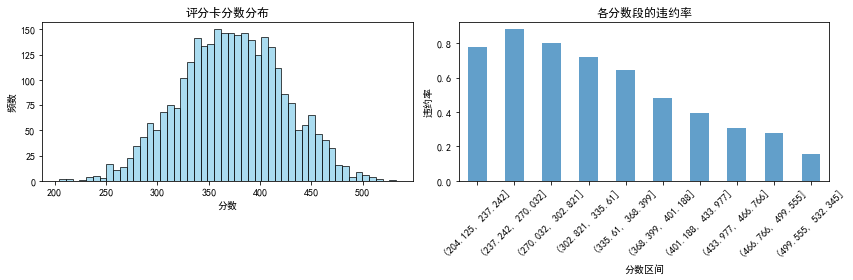


=== 评分卡统计信息 ===
分数范围: [204.5, 532.3]
平均分数: 372.6
中位数分数: 372.6

=== 详细评分卡 ===
basepoints: 374.2701分
age (17.999, 28.0]: -25.5533分
age (28.0, 38.0]: -11.0358分
age (38.0, 49.0]: -3.3279分
age (49.0, 59.0]: 13.9984分
age (59.0, 69.0]: 27.4134分
income (9999.999, 33276.227]: -16.2613分
income (33276.227, 44791.425]: -12.4542分
income (44791.425, 54878.581]: 0.0969分
income (54878.581, 66892.387]: 5.5736分
income (66892.387, 120581.104]: 22.5691分
credit_amount (999.999, 57717.952]: 48.8156分
credit_amount (57717.952, 87609.713]: 15.048分
credit_amount (87609.713, 112271.045]: -3.4118分
credit_amount (112271.045, 142434.493]: -15.4546分
credit_amount (142434.493, 300000.0]: -47.8586分
employment_years (-0.0009723, 1.11]: -16.2263分
employment_years (1.11, 2.528]: -9.9271分
employment_years (2.528, 4.528]: -4.0225分
employment_years (4.528, 8.037]: 0.4106分
employment_years (8.037, 30.0]: 29.3133分
existing_loans (-0.001, 1.0]: 17.1977分
existing_loans (1.0, 2.0]: -7.0139分
existing_loans (2.0, 9.0]: -43.7884分


In [9]:
# 计算每个样本的评分卡得分
def calculate_score(row, score_card_df):
    """计算单个样本的评分卡得分"""
    total_score = score_card_df[score_card_df['variable'] == 'basepoints']['points'].iloc[0]
    
    for _, card_row in score_card_df[score_card_df['variable'] != 'basepoints'].iterrows():
        feature = card_row['variable']
        bin_interval = card_row['bin']
        points = card_row['points']
        
        if isinstance(bin_interval, pd.Interval):
            if row[feature] in bin_interval:
                total_score += points
        else:
            # 处理特殊情况
            pass
            
    return total_score

# 由于样本级别的评分计算较复杂，我们使用模型概率来近似计算分数
def probability_to_score(prob, base_score, odds_score, odds):
    """将概率转换为分数"""
    b = odds_score / np.log(2)
    a = base_score + b * np.log(odds)
    score = a - b * np.log(prob / (1 - prob + 1e-8))
    return score

# 计算测试集的分数
test_scores = probability_to_score(y_pred_proba, base_score, odds_score, odds)

# 分析分数分布
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(test_scores, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('评分卡分数分布')
plt.xlabel('分数')
plt.ylabel('频数')

plt.subplot(1, 2, 2)
# 按分数分组计算违约率
score_bins = pd.cut(test_scores, bins=10)
default_rates = pd.DataFrame({
    'score_bin': score_bins,
    'default': y_test.values
}).groupby('score_bin')['default'].mean()

default_rates.plot(kind='bar', alpha=0.7)
plt.title('各分数段的违约率')
plt.xlabel('分数区间')
plt.ylabel('违约率')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 输出评分卡统计信息
print("\n=== 评分卡统计信息 ===")
print(f"分数范围: [{test_scores.min():.1f}, {test_scores.max():.1f}]")
print(f"平均分数: {test_scores.mean():.1f}")
print(f"中位数分数: {np.median(test_scores):.1f}")

# 显示详细的评分卡
print("\n=== 详细评分卡 ===")
for _, row in score_card.iterrows():
    if pd.isna(row['bin']):
        print(f"{row['variable']}: {row['points']}分")
    else:
        print(f"{row['variable']} {row['bin']}: {row['points']}分")

## 6. 验证评分卡效果

In [10]:
def comprehensive_scorecard_validation(scores, probabilities, y_true):
    """全面的评分卡验证"""
    from sklearn.metrics import roc_auc_score, roc_curve
    
    # 计算AUC
    auc_prob = roc_auc_score(y_true, probabilities)
    auc_score = roc_auc_score(y_true, -scores)  # 分数反转
    
    # 计算KS值
    def calculate_ks(pred, y_true):
        fpr, tpr, thresholds = roc_curve(y_true, pred)
        return np.max(tpr - fpr)
    
    ks_prob = calculate_ks(probabilities, y_true)
    ks_score = calculate_ks(-scores, y_true)  # 分数反转
    
    # 创建验证DataFrame
    validation_df = pd.DataFrame({
        '概率': probabilities,
        '分数': scores,
        '实际标签': y_true.values
    })
    
    # 按概率和分数排序的相关性
    prob_rank = validation_df['概率'].rank()
    score_rank = validation_df['分数'].rank(ascending=False)  # 分数越高排名越好
    
    rank_correlation = prob_rank.corr(score_rank)
    
    print("=== 评分卡验证结果 ===")
    print(f"概率模型 AUC: {auc_prob:.6f}")
    print(f"评分卡 AUC: {auc_score:.6f}")
    print(f"概率模型 KS: {ks_prob:.6f}")
    print(f"评分卡 KS: {ks_score:.6f}")
    print(f"概率与分数排名相关性: {rank_correlation:.6f}")
    
    return {
        'auc_prob': auc_prob,
        'auc_score': auc_score,
        'ks_prob': ks_prob,
        'ks_score': ks_score,
        'rank_correlation': rank_correlation
    }

# 执行全面验证
results = comprehensive_scorecard_validation(test_scores, y_pred_proba, y_test)

=== 评分卡验证结果 ===
概率模型 AUC: 0.686556
评分卡 AUC: 0.686556
概率模型 KS: 0.289895
评分卡 KS: 0.289895
概率与分数排名相关性: 1.000000


## At Last.好课推荐
### 1）100天风控专家

贷前策略实战项目，4大真实贷前场景实战项目，SQL+Python代码实操

内容详情介绍👉[《贷前策略实战项目（提高班）》](https://mp.weixin.qq.com/s/33nsHN3v_Zf9sPkr-yp_iA)，下单链接👉[点这里](https://bzavt.xetlk.com/s/4io33W)

### 2）pandas进阶宝典

Pandas数据分析的各种骚操作，东哥的原创笔记， 500页飞书图文笔记，近30万字，已经完全体。配套完整代码支持下载，永久访问权限。

内容详情介绍👉[《pandas进阶宝典》](https://mp.weixin.qq.com/s/9WbDFamcK2WywagdfN_f9Q)，包括5大核心图文，下单链接👉[点这里](https://app7hmmvkwr2019.h5.xiaoeknow.com/p/course/ecourse/course_2YD5u0x8FzrAIyM8soEuxnTkP9r)
- 《pandas快速入门》
- 《pandas进阶宝典》
- 《pandas实战项目》
- 《pandas进阶题库》
- 《Numpy速查手册》
- 《正则表达式手册》

以上如有不清楚也可加我微信：`Petery_1966` 咨询